# 07 — Model Comparison

Loads the predictions saved by each model notebook and compares them side by side.

**Prerequisites:** run notebooks 03, 04, 05, and 06 first so their result CSVs exist in `data/results/`.

Models compared:
- Moving Average (baseline)
- ARIMA
- XGBoost
- LSTM

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

## Parameters

In [25]:
TICKER = 'AAPL'

MODELS = {
    'Moving Average': f'../data/results/moving_average_{TICKER}.csv',
    'ARIMA':          f'../data/results/arima_{TICKER}.csv',
    'XGBoost':        f'../data/results/xgboost_{TICKER}.csv',
    'LSTM':           f'../data/results/lstm_{TICKER}.csv',
}

## Load Results

In [26]:
results = {}

for model_name, path in MODELS.items():
    df = pd.read_csv(path, index_col='Date', parse_dates=True)
    results[model_name] = df
    print(f"{model_name:<20} — {len(df)} rows")

# Align all models to the common index
# XGBoost has 301 rows (last row dropped — no next-day actual price)
# All other models have 302 rows — we trim to match
common_index = results['XGBoost'].index
for model_name in results:
    results[model_name] = results[model_name].loc[
        results[model_name].index.isin(common_index)
    ]

print(f"\nAligned to {len(common_index)} common rows (last test day excluded — no next-day price)")
for model_name, df in results.items():
    print(f"  {model_name:<20} — {len(df)} rows")


Moving Average       — 302 rows
ARIMA                — 302 rows
XGBoost              — 301 rows
LSTM                 — 302 rows

Aligned to 301 common rows (last test day excluded — no next-day price)
  Moving Average       — 301 rows
  ARIMA                — 301 rows
  XGBoost              — 301 rows
  LSTM                 — 301 rows


## Metrics

We compute three metrics for each model:

- **MAE** (Mean Absolute Error): average absolute difference in USD — easy to interpret
- **RMSE** (Root Mean Squared Error): penalizes large errors more than MAE
- **MAPE** (Mean Absolute Percentage Error): percentage error — comparable across different price levels

In [27]:
metrics = []

for model_name, df in results.items():
    actuals     = df['Actual'].values
    predictions = df['Predicted'].values

    mae  = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100

    metrics.append({'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape})

metrics_df = pd.DataFrame(metrics).set_index('Model')
metrics_df = metrics_df.sort_values('RMSE')  # best model first

print(metrics_df.round(4).to_string())

                    MAE     RMSE  MAPE (%)
Model                                     
ARIMA            2.6936   4.0512    1.2012
LSTM             6.3052   8.7706    2.5795
Moving Average   9.3565  11.6698    4.0815
XGBoost         16.9743  23.9767    6.7833


## Metrics Bar Chart

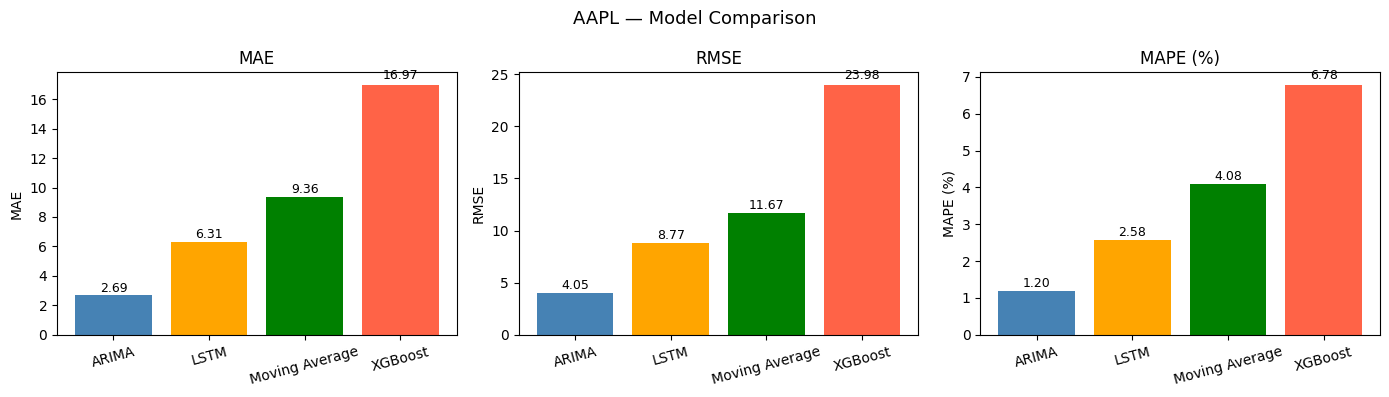

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'{TICKER} — Model Comparison', fontsize=13)

colors = ['steelblue', 'orange', 'green', 'tomato']

for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE (%)']):
    bars = ax.bar(metrics_df.index, metrics_df[metric], color=colors)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)

    # Label each bar with its value
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.show()

## All Models vs Actual

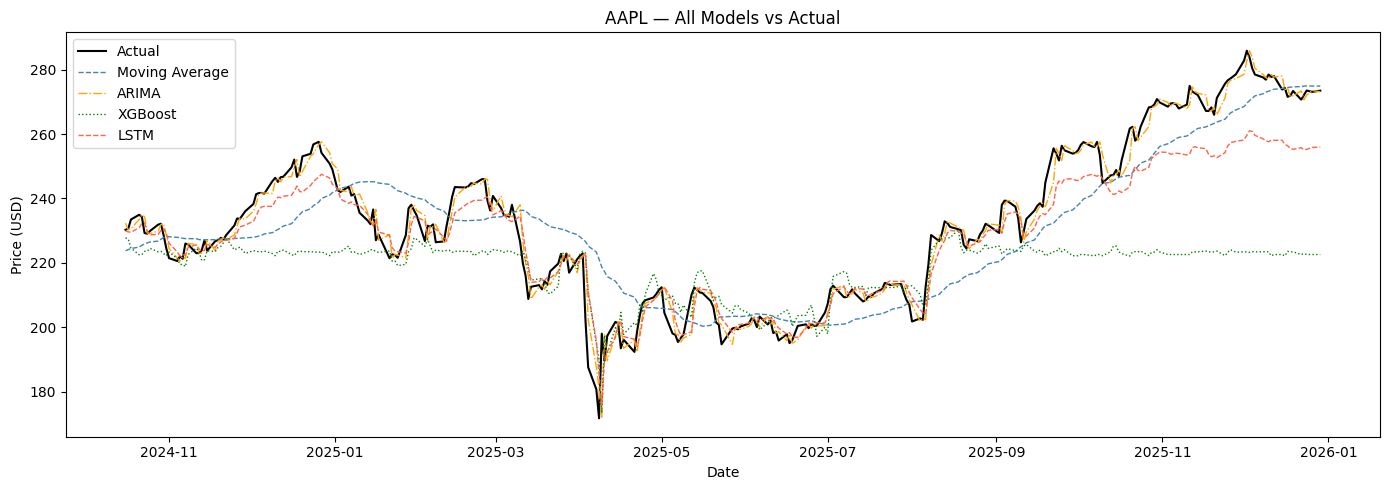

In [29]:
fig, ax = plt.subplots(figsize=(14, 5))

# Plot actual prices once (use any model's Actual column — they're the same)
first = list(results.values())[0]
ax.plot(first.index, first['Actual'], label='Actual', color='black', linewidth=1.5)

linestyles = ['--', '-.', ':', '--']
for (model_name, df), ls, color in zip(results.items(), linestyles, colors):
    ax.plot(df.index, df['Predicted'], label=model_name, linestyle=ls, color=color, linewidth=1)

ax.set_title(f'{TICKER} — All Models vs Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

## Individual Model Subplots

One subplot per model to see each prediction clearly without overlap.

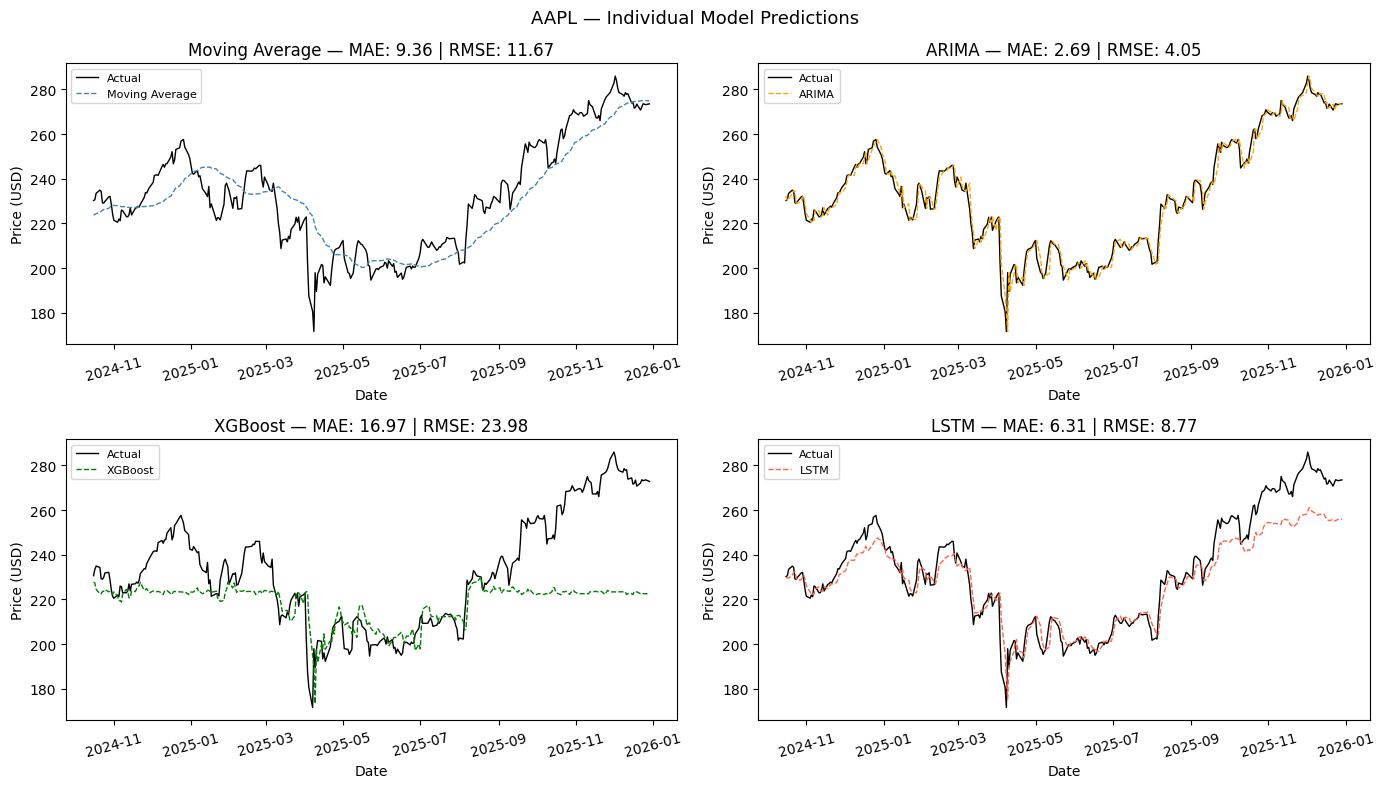

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f'{TICKER} — Individual Model Predictions', fontsize=13)
axes = axes.flatten()

for ax, (model_name, df), color in zip(axes, results.items(), colors):
    ax.plot(df.index, df['Actual'],    label='Actual',     color='black', linewidth=1)
    ax.plot(df.index, df['Predicted'], label=model_name,   color=color,   linewidth=1, linestyle='--')

    mae  = mean_absolute_error(df['Actual'], df['Predicted'])
    rmse = np.sqrt(mean_squared_error(df['Actual'], df['Predicted']))
    ax.set_title(f'{model_name} — MAE: {mae:.2f} | RMSE: {rmse:.2f}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()